# 02. ResNet学習

PTB-XLデータセットで1D-ResNetを学習

In [1]:
# インポートと設定
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report
from pathlib import Path
import os
import copy

# 日本語フォント
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.family'] = 'MS Gothic'

# 設定
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE = 256  # 大きく変更
EPOCHS = 50
LR = 1e-3  # 下げる

# データディレクトリ
DATA_DIR = Path("../data/ptb-xl")

# 5クラス定義
CLASS_NAMES = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
CLASS_NAMES_JP = ['正常', '心筋梗塞', 'ST-T変化', '伝導障害', '心肥大']
NUM_CLASSES = 5

# Early Stopping設定（F1監視、patience短く）
PATIENCE = 8

# マルチラベル分類の閾値
THRESHOLD = 0.5

# Dropout率
DROPOUT = 0.3

print(f'Device: {DEVICE}')
print(f'Epochs: {EPOCHS} (Early Stopping patience={PATIENCE}, Val F1監視)')
print(f'Batch Size: {BATCH_SIZE}')
print(f'Learning Rate: {LR}')
print(f'閾値: {THRESHOLD}')
print(f'Dropout: {DROPOUT}')
print(f'タスク: マルチラベル分類 ({NUM_CLASSES}クラス)')

Device: cuda
Epochs: 50 (Early Stopping patience=8, Val F1監視)
Batch Size: 256
Learning Rate: 0.001
閾値: 0.5
Dropout: 0.3
タスク: マルチラベル分類 (5クラス)


In [2]:
# データ読み込み（Kaggle reformatted版）
# テスト用にデータ数を制限（後でコメントアウトして全件使用）
TEST_MODE = False  # Falseにすると全件使用
N_SAMPLES = 2000 if TEST_MODE else None

train_df = pd.read_csv(DATA_DIR / "train_meta.csv")
valid_df = pd.read_csv(DATA_DIR / "valid_meta.csv")
test_df = pd.read_csv(DATA_DIR / "test_meta.csv")

# テストモードの場合は先頭N_SAMPLES件のみ使用
if TEST_MODE:
    train_df = train_df.head(N_SAMPLES)
    valid_df = valid_df.head(min(N_SAMPLES, len(valid_df)))
    test_df = test_df.head(min(N_SAMPLES, len(test_df)))
    print(f"【テストモード】各データセット先頭{N_SAMPLES}件のみ使用")

# ecg_idをインデックスに設定
train_df.set_index('ecg_id', inplace=True)
valid_df.set_index('ecg_id', inplace=True)
test_df.set_index('ecg_id', inplace=True)

print(f"Trainデータ数: {len(train_df)}件")
print(f"Validデータ数: {len(valid_df)}件")
print(f"Testデータ数: {len(test_df)}件")

# 5クラスのラベル列
CLASS_NAMES = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
CLASS_NAMES_JP = ['正常', '心筋梗塞', 'ST-T変化', '伝導障害', '心肥大']

print(f"\n【Trainデータ - 5クラス分布】")
class_counts = []
for i, name in enumerate(CLASS_NAMES):
    count = train_df[name].sum()
    class_counts.append(count)
    print(f"  {i}: {name} ({CLASS_NAMES_JP[i]}): {int(count)}件")

# pos_weight計算（HYPを強化）
# 自動計算 + HYP専用ブースト
pos_weights = []
total = len(train_df)
for i, count in enumerate(class_counts):
    pos_weight = (total - count) / (count + 1e-6)
    # HYP（インデックス4）を2倍に強化
    if i == 4:  # HYP
        pos_weight *= 2.0
    pos_weights.append(pos_weight)
    print(f"  pos_weight[{name}]: {pos_weight:.2f}")

# tensorに変換
POS_WEIGHT = torch.tensor(pos_weights).to(DEVICE)
print(f"\nPOS_WEIGHT: {POS_WEIGHT}")

Trainデータ数: 17441件
Validデータ数: 2193件
Testデータ数: 2203件

【Trainデータ - 5クラス分布】
  0: NORM (正常): 7607件
  1: MI (心筋梗塞): 4389件
  2: STTC (ST-T変化): 4193件
  3: CD (伝導障害): 3912件
  4: HYP (心肥大): 2121件
  pos_weight[HYP]: 1.29
  pos_weight[HYP]: 2.97
  pos_weight[HYP]: 3.16
  pos_weight[HYP]: 3.46
  pos_weight[HYP]: 14.45

POS_WEIGHT: tensor([ 1.2928,  2.9738,  3.1596,  3.4583, 14.4460], device='cuda:0',
       dtype=torch.float64)


In [3]:
# 信号データを.npyファイルに変換（最初だけ実行）
import gc

def convert_signal_to_npy(df_meta, signal_csv_path, output_dir, target_length=1000):
    """signal.csvから.npyファイルに変換して保存"""
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    
    signal_df = pd.read_csv(signal_csv_path)
    print(f"信号データ変換: {len(df_meta)}件")
    
    for idx, (_, row) in enumerate(df_meta.iterrows()):
        if (idx + 1) % 500 == 0:
            print(f"  {idx + 1}/{len(df_meta)}件変換完了", end='\r')
        
        ecg_id = row.name
        npy_path = output_dir / f"{ecg_id}.npy"
        
        # すでに存在する場合はスキップ
        if npy_path.exists():
            continue
        
        try:
            record_signal = signal_df[signal_df['ecg_id'] == ecg_id].iloc[:, 1:13].astype(float).values.T
            
            if record_signal.shape[1] >= target_length:
                signal = record_signal[:, :target_length]
            else:
                pad = target_length - record_signal.shape[1]
                signal = np.pad(record_signal, ((0, 0), (0, pad)), mode='constant')
            
            # 正規化
            for i in range(12):
                s = signal[i]
                if s.std() > 1e-6:
                    signal[i] = (s - s.mean()) / s.std()
            
            np.save(npy_path, signal.astype(np.float32))
        except Exception as e:
            if idx < 3:
                print(f"  エラー: ecg_id={ecg_id}, {e}")
    
    print(f"\n変換完了: {output_dir}")

# 実行（初回のみ）
print("信号データを.npyファイルに変換します（初回のみ実行）")
convert_signal_to_npy(train_df, DATA_DIR / "train_signal.csv", DATA_DIR / "train_signals")
convert_signal_to_npy(valid_df, DATA_DIR / "valid_signal.csv", DATA_DIR / "valid_signals")
convert_signal_to_npy(test_df, DATA_DIR / "test_signal.csv", DATA_DIR / "test_signals")
print("npyファイル変換完了")

# メモリ解放
gc.collect()

信号データを.npyファイルに変換します（初回のみ実行）
信号データ変換: 17441件
  17000/17441件変換完了
変換完了: ..\data\ptb-xl\train_signals
信号データ変換: 2193件
  2000/2193件変換完了
変換完了: ..\data\ptb-xl\valid_signals
信号データ変換: 2203件
  2000/2203件変換完了
変換完了: ..\data\ptb-xl\test_signals
npyファイル変換完了


20

In [4]:
# Datasetクラス（.npyファイルから読み込む版）
class PTBXLDataset(Dataset):
    def __init__(self, df_meta, signal_dir):
        # ecg_idを残してreset_index
        self.df_meta = df_meta.reset_index()
        self.signal_dir = Path(signal_dir)
        self.signals = []
        self.labels = []
        
        print(f"データを{len(df_meta)}件読み込み中...")
        for idx, row in self.df_meta.iterrows():
            ecg_id = row['ecg_id']
            npy_path = self.signal_dir / f"{ecg_id}.npy"
            
            if npy_path.exists():
                signal = np.load(npy_path)
                self.signals.append(signal)
                labels = row[CLASS_NAMES].values.astype(np.float32)
                self.labels.append(labels)
            else:
                print(f"  警告: {npy_path}が見つかりません")
        
        print(f"読み込み完了: {len(self.signals)}件")
    
    def __len__(self):
        return len(self.signals)
    
    def __getitem__(self, idx):
        return torch.from_numpy(self.signals[idx]), torch.from_numpy(self.labels[idx])

print("Datasetクラス定義完了（.npy版）")

Datasetクラス定義完了（.npy版）


In [5]:
# Dataset作成（.npyファイルから読み込み）
train_dataset = PTBXLDataset(train_df, DATA_DIR / "train_signals")
valid_dataset = PTBXLDataset(valid_df, DATA_DIR / "valid_signals")
test_dataset = PTBXLDataset(test_df, DATA_DIR / "test_signals")

print(f"\nDatasetサイズ:")
print(f"  Train: {len(train_dataset)}件")
print(f"  Valid: {len(valid_dataset)}件")
print(f"  Test: {len(test_dataset)}件")

データを17441件読み込み中...
読み込み完了: 17441件
データを2193件読み込み中...
読み込み完了: 2193件
データを2203件読み込み中...
読み込み完了: 2203件

Datasetサイズ:
  Train: 17441件
  Valid: 2193件
  Test: 2203件


In [6]:
# DataLoader作成
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"DataLoader作成完了:")
print(f"  Train: {len(train_loader)}バッチ")
print(f"  Valid: {len(valid_loader)}バッチ")
print(f"  Test: {len(test_loader)}バッチ")

# データ形状確認
signals, labels = next(iter(train_loader))
print(f"\nバッチデータ形状:")
print(f"  Signals: {signals.shape} (batch, channels, length)")
print(f"  Labels: {labels.shape} (batch, num_classes)")

DataLoader作成完了:
  Train: 69バッチ
  Valid: 9バッチ
  Test: 9バッチ

バッチデータ形状:
  Signals: torch.Size([256, 12, 1000]) (batch, channels, length)
  Labels: torch.Size([256, 5]) (batch, num_classes)


In [7]:
# ResNet1Dモデル定義（Dropout追加）
class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None, dropout=0.3):
        super(ResBlock, self).__init__()
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=7, stride=stride, padding=3, bias=False)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout(dropout)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=7, stride=1, padding=3, bias=False)
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.downsample = downsample
    
    def forward(self, x):
        identity = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.conv2(out)
        out = self.bn2(out)
        if self.downsample is not None:
            identity = self.downsample(x)
        out += identity
        out = self.relu(out)
        return out

class ResNet1D(nn.Module):
    def __init__(self, in_channels=12, num_classes=5, dropout=0.3):
        super(ResNet1D, self).__init__()
        self.in_channels = 64
        self.conv1 = nn.Conv1d(in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm1d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool1d(kernel_size=3, stride=2, padding=1)
        
        self.layer1 = self._make_layer(64, 2, dropout=dropout)
        self.layer2 = self._make_layer(128, 2, stride=2, dropout=dropout)
        self.layer3 = self._make_layer(256, 2, stride=2, dropout=dropout)
        self.layer4 = self._make_layer(512, 2, stride=2, dropout=dropout)
        
        self.avgpool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(512, num_classes)
        self.dropout = nn.Dropout(dropout)
        
    def _make_layer(self, out_channels, blocks, stride=1, dropout=0.3):
        downsample = None
        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv1d(self.in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm1d(out_channels)
            )
        layers = []
        layers.append(ResBlock(self.in_channels, out_channels, stride, downsample, dropout))
        self.in_channels = out_channels
        for _ in range(1, blocks):
            layers.append(ResBlock(out_channels, out_channels, dropout=dropout))
        return nn.Sequential(*layers)
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc(x)
        return x

# モデル作成
model = ResNet1D(in_channels=12, num_classes=NUM_CLASSES, dropout=DROPOUT).to(DEVICE)
print(f"モデル作成完了: {sum(p.numel() for p in model.parameters()):,}パラメータ")

モデル作成完了: 8,733,829パラメータ


In [8]:
# 損失関数とオプティマイザ（AdamW + OneCycleLR）
criterion = nn.BCEWithLogitsLoss(pos_weight=POS_WEIGHT)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

# OneCycleLR
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer, 
    max_lr=LR * 5,  # max_lr = 5e-3
    epochs=EPOCHS, 
    steps_per_epoch=len(train_loader),
    pct_start=0.3,
    anneal_strategy='cos'
)

print("学習設定:")
print(f"  損失関数: BCEWithLogitsLoss (pos_weight付き)")
print(f"  オプティマイザ: AdamW (lr={LR}, weight_decay=1e-4)")
print(f"  スケジューラ: OneCycleLR (max_lr={LR*5})")
print(f"  POS_WEIGHT: {POS_WEIGHT.cpu().numpy()}")

学習設定:
  損失関数: BCEWithLogitsLoss (pos_weight付き)
  オプティマイザ: AdamW (lr=0.001, weight_decay=1e-4)
  スケジューラ: OneCycleLR (max_lr=0.005)
  POS_WEIGHT: [ 1.29275667  2.97379813  3.15955163  3.45833333 14.44601602]


In [9]:
# 学習・評価関数（scheduler対応）
def train_epoch(model, loader, criterion, optimizer, device, threshold=0.5, scheduler=None):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    for signals, labels in loader:
        signals = signals.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(signals)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        # OneCycleLR: 各バッチ後に更新
        if scheduler is not None:
            scheduler.step()
        
        running_loss += loss.item() * signals.size(0)
        all_preds.append((torch.sigmoid(outputs) > threshold).cpu().numpy())
        all_labels.append(labels.cpu().numpy())
    
    preds = np.vstack(all_preds)
    labels = np.vstack(all_labels)
    f1 = f1_score(labels, preds, average='macro', zero_division=0)
    
    return running_loss / len(loader.dataset), f1

def eval_epoch(model, loader, criterion, device, threshold=0.5):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for signals, labels in loader:
            signals = signals.to(device)
            labels = labels.to(device)
            
            outputs = model(signals)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * signals.size(0)
            all_preds.append((torch.sigmoid(outputs) > threshold).cpu().numpy())
            all_labels.append(labels.cpu().numpy())
    
    preds = np.vstack(all_preds)
    labels = np.vstack(all_labels)
    f1 = f1_score(labels, preds, average='macro', zero_division=0)
    
    return running_loss / len(loader.dataset), f1

print("学習関数定義完了")

学習関数定義完了


In [10]:
# 学習ループ（Valid F1でEarly Stopping）
import time

history = {'train_loss': [], 'train_f1': [], 'valid_loss': [], 'valid_f1': []}
best_model_wts = copy.deepcopy(model.state_dict())
best_f1 = 0.0
patience_counter = 0
start_time = time.time()

print("学習開始...")
for epoch in range(EPOCHS):
    epoch_start = time.time()
    
    train_loss, train_f1 = train_epoch(model, train_loader, criterion, optimizer, DEVICE, threshold=THRESHOLD, scheduler=scheduler)
    valid_loss, valid_f1 = eval_epoch(model, valid_loader, criterion, DEVICE, threshold=THRESHOLD)
    
    history['train_loss'].append(train_loss)
    history['train_f1'].append(train_f1)
    history['valid_loss'].append(valid_loss)
    history['valid_f1'].append(valid_f1)
    
    # Early Stopping（Valid F1で監視）
    if valid_f1 > best_f1:
        best_f1 = valid_f1
        best_model_wts = copy.deepcopy(model.state_dict())
        patience_counter = 0
        is_best = "(★ベスト)"
    else:
        patience_counter += 1
        is_best = ""
    
    epoch_time = time.time() - epoch_start
    print(f"Epoch {epoch+1}/{EPOCHS} ({epoch_time:.1f}s) - "
          f"Train Loss: {train_loss:.4f}, F1: {train_f1:.4f} | "
          f"Valid Loss: {valid_loss:.4f}, F1: {valid_f1:.4f}{is_best}")
    
    if patience_counter >= PATIENCE:
        print(f"\nEarly Stopping発動 (patience={PATIENCE})")
        break

total_time = time.time() - start_time
print(f"\n学習完了! 所要時間: {total_time/60:.1f}分")
print(f"ベストValidation F1: {best_f1:.4f}")

# ベストモデルをロード
model.load_state_dict(best_model_wts)

学習開始...
Epoch 1/50 (7.3s) - Train Loss: 0.8634, F1: 0.5642 | Valid Loss: 1.1352, F1: 0.5576(★ベスト)
Epoch 2/50 (6.7s) - Train Loss: 0.7316, F1: 0.6313 | Valid Loss: 0.8639, F1: 0.6371(★ベスト)
Epoch 3/50 (6.6s) - Train Loss: 0.7074, F1: 0.6411 | Valid Loss: 0.9360, F1: 0.6325
Epoch 4/50 (6.6s) - Train Loss: 0.6866, F1: 0.6512 | Valid Loss: 0.9453, F1: 0.5930
Epoch 5/50 (6.6s) - Train Loss: 0.6685, F1: 0.6609 | Valid Loss: 0.8127, F1: 0.6484(★ベスト)
Epoch 6/50 (6.6s) - Train Loss: 0.6519, F1: 0.6656 | Valid Loss: 0.8485, F1: 0.6030
Epoch 7/50 (6.6s) - Train Loss: 0.6545, F1: 0.6676 | Valid Loss: 0.8704, F1: 0.6249
Epoch 8/50 (6.7s) - Train Loss: 0.6348, F1: 0.6740 | Valid Loss: 0.9446, F1: 0.5975
Epoch 9/50 (6.6s) - Train Loss: 0.6243, F1: 0.6803 | Valid Loss: 0.9228, F1: 0.6054
Epoch 10/50 (6.7s) - Train Loss: 0.6384, F1: 0.6725 | Valid Loss: 0.7259, F1: 0.6515(★ベスト)
Epoch 11/50 (6.6s) - Train Loss: 0.6123, F1: 0.6863 | Valid Loss: 0.7796, F1: 0.6292
Epoch 12/50 (6.6s) - Train Loss: 0.6033, F

<All keys matched successfully>

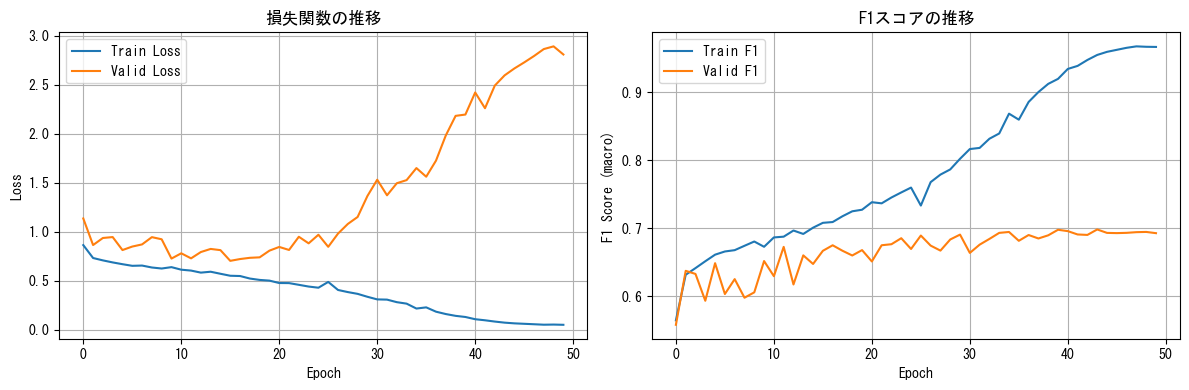

学習曲線を保存: ../images/resnet1d_learning_curve.png


In [11]:
# 学習曲線の可視化
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss
axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['valid_loss'], label='Valid Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('損失関数の推移')
axes[0].legend()
axes[0].grid(True)

# F1 Score
axes[1].plot(history['train_f1'], label='Train F1')
axes[1].plot(history['valid_f1'], label='Valid F1')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1 Score (macro)')
axes[1].set_title('F1スコアの推移')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('../images/resnet1d_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print("学習曲線を保存: ../images/resnet1d_learning_curve.png")

In [12]:
# モデル保存
os.makedirs('../models', exist_ok=True)
torch.save(model.state_dict(), '../models/resnet1d_ptbxl.pth')
print("モデルを保存: ../models/resnet1d_ptbxl.pth")

モデルを保存: ../models/resnet1d_ptbxl.pth


In [13]:
# テストデータで評価
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for signals, labels in test_loader:
        signals = signals.to(DEVICE)
        outputs = model(signals)
        preds = (torch.sigmoid(outputs) > THRESHOLD).cpu().numpy()
        all_preds.append(preds)
        all_labels.append(labels.numpy())

test_preds = np.vstack(all_preds)
test_labels = np.vstack(all_labels)

# F1スコア（macro）
test_f1_macro = f1_score(test_labels, test_preds, average='macro', zero_division=0)
test_f1_micro = f1_score(test_labels, test_preds, average='micro', zero_division=0)

print(f"\n【テスト評価結果】")
print(f"F1 Score (macro): {test_f1_macro:.4f}")
print(f"F1 Score (micro): {test_f1_micro:.4f}")

# 各クラスのF1スコア
print(f"\n【各クラスのF1スコア】")
for i, name in enumerate(CLASS_NAMES):
    f1 = f1_score(test_labels[:, i], test_preds[:, i], zero_division=0)
    print(f"  {name} ({CLASS_NAMES_JP[i]}): {f1:.4f}")

# Classification Report
print(f"\n【Classification Report】")
print(classification_report(test_labels, test_preds, target_names=CLASS_NAMES, zero_division=0))


【テスト評価結果】
F1 Score (macro): 0.6885
F1 Score (micro): 0.7364

【各クラスのF1スコア】
  NORM (正常): 0.8421
  MI (心筋梗塞): 0.7119
  STTC (ST-T変化): 0.7261
  CD (伝導障害): 0.7175
  HYP (心肥大): 0.4452

【Classification Report】
              precision    recall  f1-score   support

        NORM       0.77      0.93      0.84       964
          MI       0.72      0.70      0.71       553
        STTC       0.71      0.74      0.73       523
          CD       0.73      0.71      0.72       498
         HYP       0.40      0.49      0.45       263

   micro avg       0.70      0.77      0.74      2801
   macro avg       0.67      0.72      0.69      2801
weighted avg       0.71      0.77      0.74      2801
 samples avg       0.73      0.77      0.73      2801



In [14]:
# 正常・異常バイナリ評価
# NORM=0, その他=1として2値分類を評価
binary_labels = (test_labels[:, 0] == 0).astype(int)  # NORM=0, 異常=1
binary_preds = (test_preds[:, 0] == 0).astype(int)

from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

# 2値分類メトリクス
binary_acc = accuracy_score(binary_labels, binary_preds)
binary_prec = precision_score(binary_labels, binary_preds, pos_label=1)  # 異常のprecision
binary_rec = recall_score(binary_labels, binary_preds, pos_label=1)  # 異常のrecall
binary_f1 = f1_score(binary_labels, binary_preds, pos_label=1)

# Confusion Matrix
cm = confusion_matrix(binary_labels, binary_preds)

print(f"\n【正常・異常バイナリ評価】")
print(f"正解率: {binary_acc:.4f}")
print(f"適合率: {binary_prec:.4f}")
print(f"再現率: {binary_rec:.4f}")
print(f"F1スコア: {binary_f1:.4f}")

print(f"\n【Confusion Matrix】")
print(f"              予測: 正常    予測: 異常")
print(f"実際: 正常     {cm[0,0]:5d}       {cm[0,1]:5d}")
print(f"実際: 異常     {cm[1,0]:5d}       {cm[1,1]:5d}")

# 感度・特異度
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)  # 真陽性率（異常の見逃しなし率）
specificity = tn / (tn + fp)  # 真陰性率（正常の正しい識別率）

print(f"\n感度: {sensitivity:.4f} (異常の見逃しなし率)")
print(f"特異度: {specificity:.4f} (正常の正しい識別率)")


【正常・異常バイナリ評価】
正解率: 0.8466
適合率: 0.9387
再現率: 0.7780
F1スコア: 0.8508

【Confusion Matrix】
              予測: 正常    予測: 異常
実際: 正常       901          63
実際: 異常       275         964

感度: 0.7780 (異常の見逃しなし率)
特異度: 0.9346 (正常の正しい識別率)


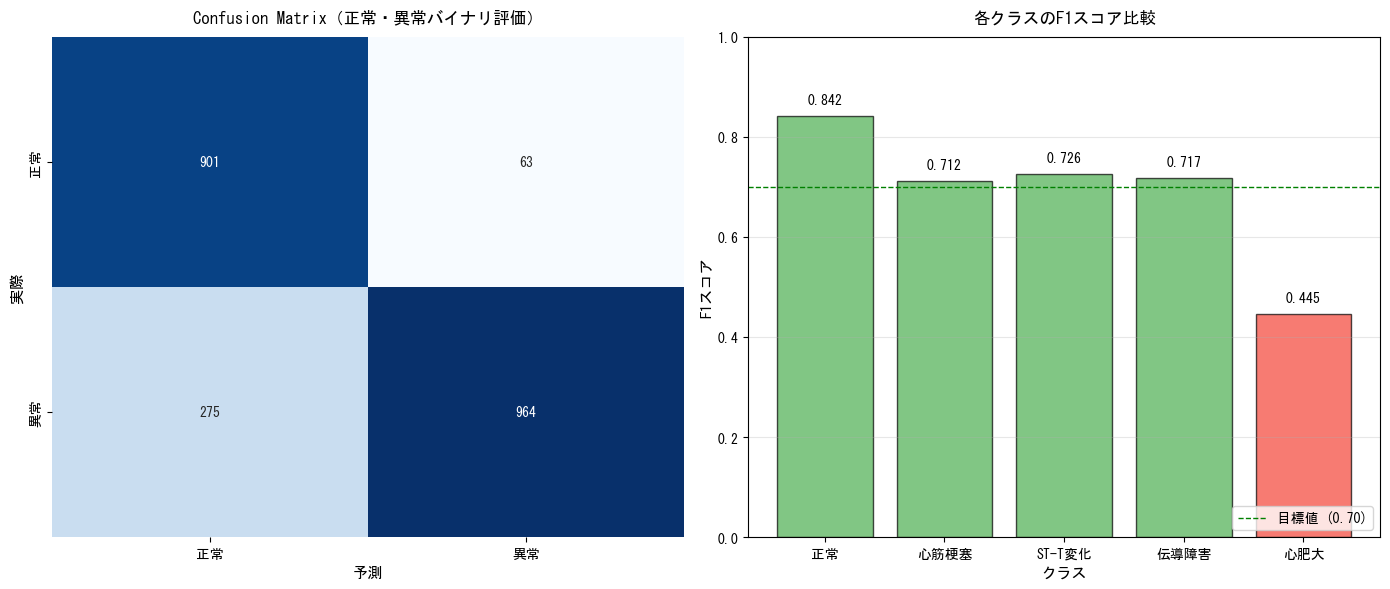

可視化を保存: ../images/resnet1d_evaluation.png


In [15]:
# 可視化：Confusion Matrixとクラス別F1スコア
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Confusion Matrix（バイナリ評価）
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0])
axes[0].set_title('Confusion Matrix（正常・異常バイナリ評価）', fontsize=12, pad=10)
axes[0].set_xlabel('予測', fontsize=11)
axes[0].set_ylabel('実際', fontsize=11)
axes[0].set_xticks([0.5, 1.5])
axes[0].set_yticks([0.5, 1.5])
axes[0].set_xticklabels(['正常', '異常'])
axes[0].set_yticklabels(['正常', '異常'])

# 各クラスのF1スコア比較
class_f1_scores = [
    f1_score(test_labels[:, i], test_preds[:, i], zero_division=0) 
    for i in range(len(CLASS_NAMES))
]
colors = ['#4CAF50' if f >= 0.7 else '#FFC107' if f >= 0.5 else '#F44336' for f in class_f1_scores]
bars = axes[1].bar(CLASS_NAMES_JP, class_f1_scores, color=colors, edgecolor='black', alpha=0.7)
axes[1].axhline(y=0.7, color='green', linestyle='--', linewidth=1, label='目標値 (0.70)')
axes[1].set_xlabel('クラス', fontsize=11)
axes[1].set_ylabel('F1スコア', fontsize=11)
axes[1].set_title('各クラスのF1スコア比較', fontsize=12, pad=10)
axes[1].set_ylim(0, 1.0)
axes[1].legend(loc='lower right')
axes[1].grid(axis='y', alpha=0.3)

# バーの上に数値を表示
for bar, score in zip(bars, class_f1_scores):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{score:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('../images/resnet1d_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

print("可視化を保存: ../images/resnet1d_evaluation.png")

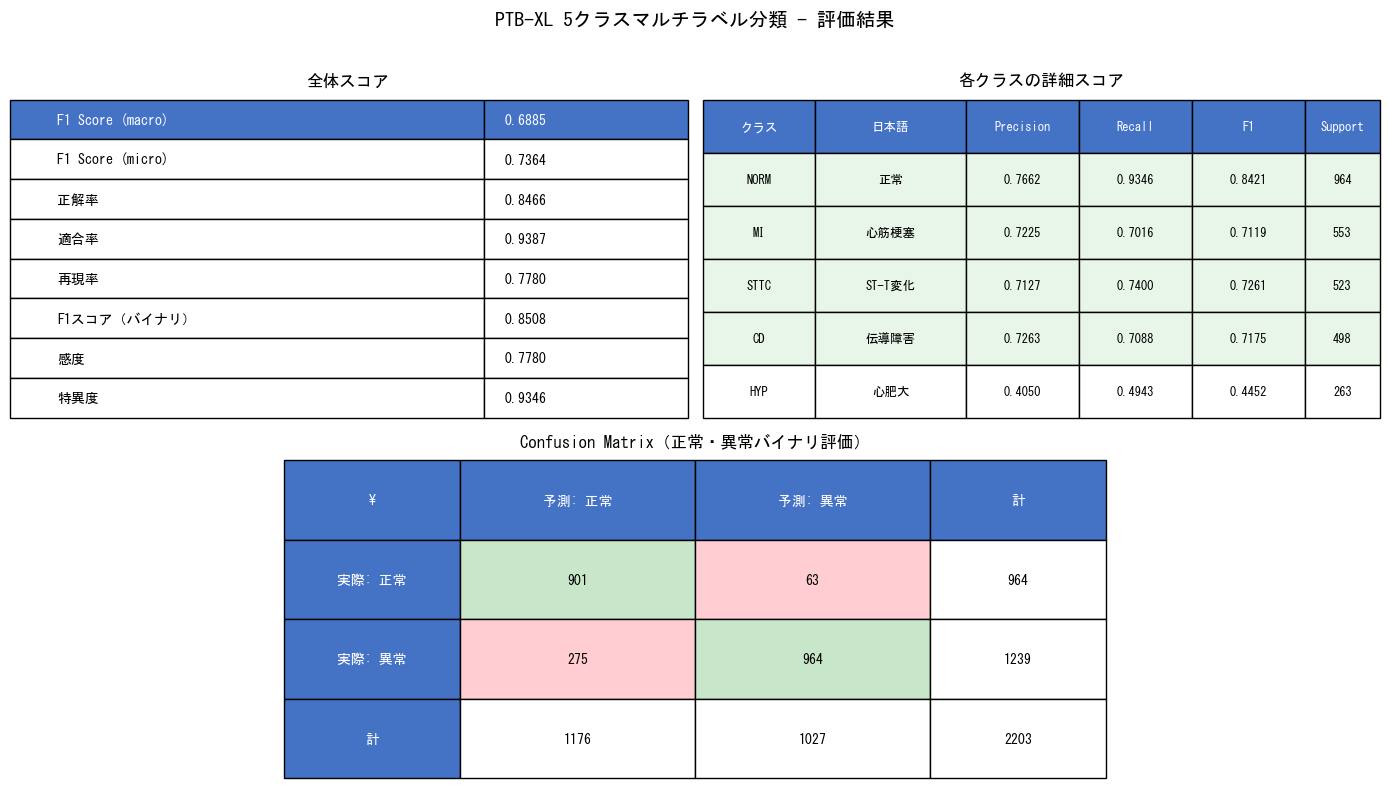

評価結果表を保存: ../images/resnet1d_results_table.png


In [16]:
# 評価結果を表形式で可視化・保存
fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1])

# 全体スコア表
ax1 = fig.add_subplot(gs[0, 0])
ax1.axis('off')
ax1.set_title('全体スコア', fontsize=12, fontweight='bold', pad=10)

overall_data = [
    ['F1 Score (macro)', f'{test_f1_macro:.4f}'],
    ['F1 Score (micro)', f'{test_f1_micro:.4f}'],
    ['正解率', f'{binary_acc:.4f}'],
    ['適合率', f'{binary_prec:.4f}'],
    ['再現率', f'{binary_rec:.4f}'],
    ['F1スコア（バイナリ）', f'{binary_f1:.4f}'],
    ['感度', f'{sensitivity:.4f}'],
    ['特異度', f'{specificity:.4f}']
]

table1 = ax1.table(cellText=overall_data, cellLoc='left', loc='center',
                    colWidths=[0.7, 0.3], bbox=[0, 0, 1, 1])
table1.auto_set_font_size(False)
table1.set_fontsize(10)
table1.scale(1, 1.5)

# ヘッダーを追加
for j in range(2):
    table1[(0, j)].set_facecolor('#4472C4')
    table1[(0, j)].set_text_props(weight='bold', color='white')

# 各クラスの詳細スコア表
ax2 = fig.add_subplot(gs[0, 1])
ax2.axis('off')
ax2.set_title('各クラスの詳細スコア', fontsize=12, fontweight='bold', pad=10)

# 各クラスのメトリクスを計算
class_detail_data = [['クラス', '日本語', 'Precision', 'Recall', 'F1', 'Support']]
for i, name in enumerate(CLASS_NAMES):
    y_true = test_labels[:, i]
    y_pred = test_preds[:, i]
    
    from sklearn.metrics import precision_score, recall_score
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    support = int(y_true.sum())
    
    class_detail_data.append([
        name, 
        CLASS_NAMES_JP[i], 
        f'{prec:.4f}', 
        f'{rec:.4f}', 
        f'{f1:.4f}', 
        str(support)
    ])

table2 = ax2.table(cellText=class_detail_data, cellLoc='center', loc='center',
                    colWidths=[0.15, 0.2, 0.15, 0.15, 0.15, 0.1], bbox=[0, 0, 1, 1])
table2.auto_set_font_size(False)
table2.set_fontsize(9)
table2.scale(1, 1.3)

# ヘッダーを装飾
for j in range(6):
    table2[(0, j)].set_facecolor('#4472C4')
    table2[(0, j)].set_text_props(weight='bold', color='white')

# F1スコアに応じて行を色分け
for i in range(1, len(CLASS_NAMES) + 1):
    f1_val = float(class_detail_data[i][4])
    if f1_val >= 0.7:
        for j in range(6):
            table2[(i, j)].set_facecolor('#E8F5E9')
    elif f1_val >= 0.5:
        for j in range(6):
            table2[(i, j)].set_facecolor('#FFFDE7')

# Confusion Matrix（バイナリ）
ax3 = fig.add_subplot(gs[1, :])
ax3.axis('off')
ax3.set_title('Confusion Matrix（正常・異常バイナリ評価）', fontsize=12, fontweight='bold', pad=10)

# Confusion Matrixの表形式
cm_data = [
    ['\\', '予測: 正常', '予測: 異常', '計'],
    ['実際: 正常', str(cm[0, 0]), str(cm[0, 1]), str(cm[0, 0] + cm[0, 1])],
    ['実際: 異常', str(cm[1, 0]), str(cm[1, 1]), str(cm[1, 0] + cm[1, 1])],
    ['計', str(cm[0, 0] + cm[1, 0]), str(cm[0, 1] + cm[1, 1]), str(cm.sum())]
]

table3 = ax3.table(cellText=cm_data, cellLoc='center', loc='center',
                    colWidths=[0.15, 0.2, 0.2, 0.15, 0.15], bbox=[0.2, 0, 0.6, 1])
table3.auto_set_font_size(False)
table3.set_fontsize(10)
table3.scale(1, 2)

# ヘッダーと対角線を装飾（列数は4）
for j in range(4):
    table3[(0, j)].set_facecolor('#4472C4')
    table3[(0, j)].set_text_props(weight='bold', color='white')
for i in range(4):
    table3[(i, 0)].set_facecolor('#4472C4')
    table3[(i, 0)].set_text_props(weight='bold', color='white')

# 正解・不正解を色分け
table3[(1, 1)].set_facecolor('#C8E6C9')  # 正常-正常（正解）
table3[(1, 2)].set_facecolor('#FFCDD2')  # 正常-異常（誤り）
table3[(2, 1)].set_facecolor('#FFCDD2')  # 異常-正常（誤り）
table3[(2, 2)].set_facecolor('#C8E6C9')  # 異常-異常（正解）

plt.suptitle('PTB-XL 5クラスマルチラベル分類 - 評価結果', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('../images/resnet1d_results_table.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("評価結果表を保存: ../images/resnet1d_results_table.png")